# **LOAD DATASET**

In [1]:
import numpy as np
import pandas as pd

In [2]:
path_file_train = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\train_processed.csv"

path_file_test = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\test_processed.csv"

df_train = pd.read_csv(path_file_train)
df_test = pd.read_csv(path_file_test)

In [3]:
X_train = df_train.drop(columns=['Exam_Score'])
y_train = df_train['Exam_Score']

X_test = df_test.drop(columns=['Exam_Score'])
y_test = df_test['Exam_Score']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5285, 22)
X_test shape: (1322, 22)


# **MODELING**

In [4]:
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)
}

In [6]:
cv_results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)


for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    cv_results.append((name, scores.mean(), scores.std()))

cv_results_df = pd.DataFrame(cv_results, columns=['Model', 'Mean R2 Score', 'Std R2 Score'])

display(cv_results_df.sort_values(by='Mean R2 Score', ascending=False).reset_index(drop=True))

,Model,Mean R2 Score,Std R2 Score
0,Ridge,0.716569,0.033770
1,Linear Regression,0.716567,0.033792
2,SVR,0.706287,0.034095
3,Random Forest,0.629606,0.029501
4,XGBoost,0.625576,0.038684
5,KNN,0.574979,0.021620
6,ElasticNet,0.495060,0.024631
7,Lasso,0.437824,0.022604
8,Decision Tree,0.178416,0.135285


# **HYPERPARAMETER TUNING**

In [7]:
param_grids = {
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'SVR': {
            'C': [0.1, 1.0, 10.0],
            'epsilon': [0.01, 0.1, 0.2],
            'kernel': ['linear', 'rbf']},
    'Random Forest': {
        'n_estimators': [200, 400],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [1, 2, 4]},
    'XGBoost': {
        'n_estimators': [200, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1]}
}


In [8]:
tuning_results = {}
best_models = {}
summary_results = []

for name, params in param_grids.items():

    model = models[name]

    grid = GridSearchCV( estimator=model, param_grid=params, cv=kf, scoring='r2', n_jobs=-1, return_train_score=True)

    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    results = pd.DataFrame(grid.cv_results_)

    results = results[
        [
            'rank_test_score',
            'mean_test_score',
            'std_test_score',
            'mean_train_score',
            'std_train_score',
            'params'
        ]
    ]

    results = results.sort_values(by='mean_test_score', ascending=False)

    results = results.reset_index(drop=True)
    tuning_results[name] = results
    summary_results.append({
        'Model': name,
        'Best CV R²': grid.best_score_,
        'Std R²': results.iloc[0]['std_test_score'],
        'Best Parameters': grid.best_params_
    })

In [9]:
tuning_summary = pd.DataFrame(summary_results)

tuning_summary = tuning_summary.sort_values(by='Best CV R²',ascending=False).reset_index(drop=True)

best_model = best_models[tuning_summary.iloc[0]['Model']]

display(tuning_summary)

,Model,Best CV R²,Std R²,Best Parameters
0,Ridge,0.716569,0.033770,{'alpha': 1.0}
1,SVR,0.715976,0.034809,"{'C': 0.1, 'epsilon': 0.2, 'kernel': 'linear'}"
2,XGBoost,0.687789,0.034794,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
3,Random Forest,0.652086,0.027465,"{'max_depth': 20, 'min_samples_leaf': 4, 'n_es..."


# **FINAL EVALUATION TEST SET**

In [10]:
best_model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary <random_state>` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"pos

In [11]:
y_pred =best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

MAE  : 0.449
MSE  : 3.241
RMSE : 1.800
R2   : 0.771


# **ANALYSIS**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

## *ACTUAL VS PREDICTED*

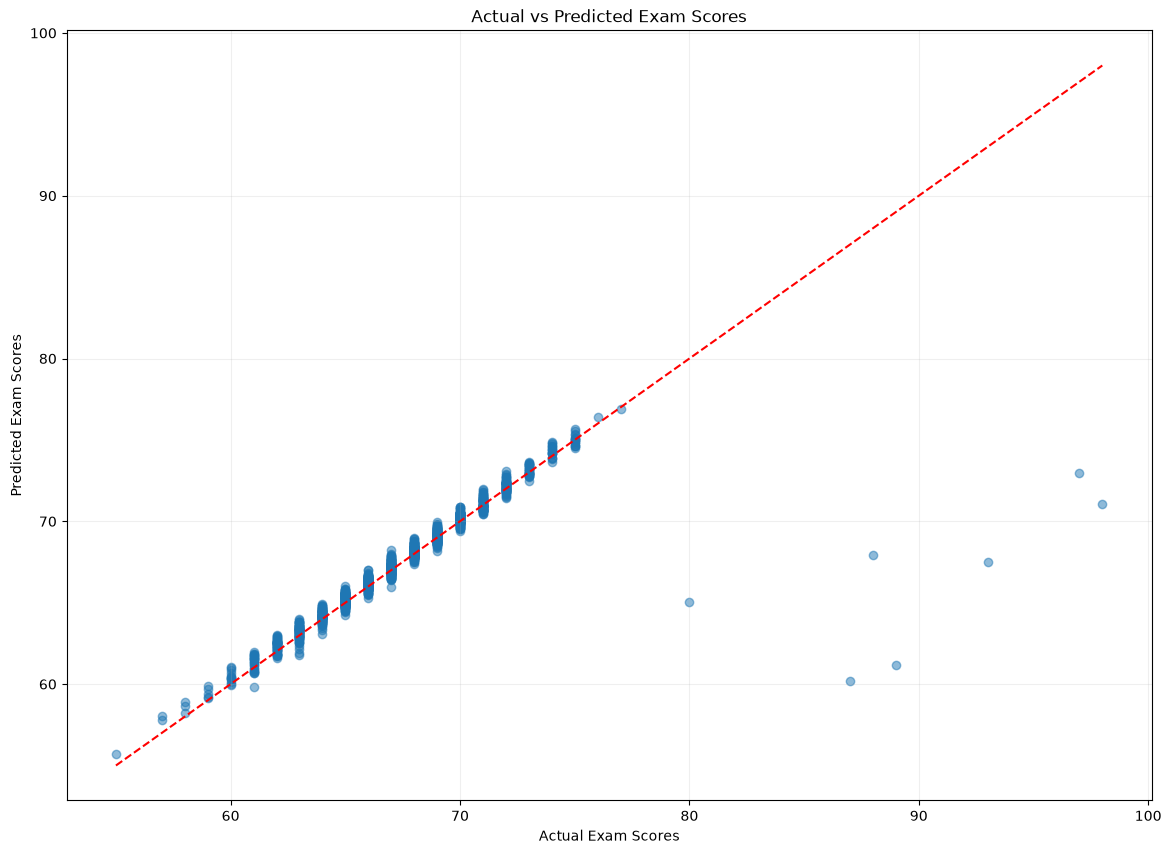

In [15]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(14, 10))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red',linestyle='--')

plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Actual vs Predicted Exam Scores')
plt.grid(alpha=0.2)

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. PREDICTION & RESIDUAL
# ==========================================

y_pred = best_model.predict(X_test)
residuals = y_test - y_pred


# ==========================================
# 2. ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Garis ideal: Actual = Predicted
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Score')

plt.grid(alpha=0.3)
plt.show()


# ==========================================
# 3. RESIDUAL ANALYSIS
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

# Garis residual = 0
plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual')
plt.title('Residual Analysis')

plt.grid(alpha=0.3)
plt.show()


# ==========================================
# 4. RESIDUAL DISTRIBUTION
# ==========================================

plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=30)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')

plt.grid(alpha=0.3)
plt.show()


# ==========================================
# 5. FEATURE IMPORTANCE
#    Khusus model yang memiliki coef_
# ==========================================

if hasattr(best_model, 'coef_'):

    feature_importance = pd.DataFrame({
        'Feature': X_test.columns,
        'Coefficient': best_model.coef_
    })

    feature_importance['Absolute Coefficient'] = (
        feature_importance['Coefficient'].abs()
    )

    feature_importance = feature_importance.sort_values(
        by='Absolute Coefficient',
        ascending=False
    ).reset_index(drop=True)

    display(feature_importance)

    # Plot
    plt.figure(figsize=(10, 7))

    plt.barh(
        feature_importance['Feature'],
        feature_importance['Coefficient']
    )

    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.title('Feature Importance - Ridge')

    plt.gca().invert_yaxis()

    plt.grid(axis='x', alpha=0.3)
    plt.show()

else:
    print(
        'Model tidak memiliki atribut coef_. '
        'Gunakan permutation importance untuk model ini.'
    )

NameError: name 'best_model' is not defined